#### Decision Tree Classifier

1.  The main aim of this project is to predict the species of the Iris Plant record using Decision Tree Classifier of Entropy technique.

2.  We can improve the accuracy of the model using Hyper Parameter Tuning of GridSearchCV method.


#### Step 1:    Import  all the necessary  libraries

In [1094]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets            import   load_iris
from    sklearn.model_selection     import   train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing       import   StandardScaler
from    sklearn.tree                import   DecisionTreeClassifier, plot_tree
from    sklearn.pipeline            import   Pipeline
from    sklearn.metrics             import   accuracy_score, confusion_matrix, classification_report

#### Step 2: Load the Dataset

In [1095]:
#### Load the iris data

data = load_iris()

#### Construct the dataframe from the data

df = pd.DataFrame(data.data, columns= data.feature_names)


#### Adding the target to the dataframe
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Step 3: Perform the Data Exploration

In [1096]:
#### get the first five rows of the dataset

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [1097]:
#### get the first five rows of the dataset

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [1098]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 150


In [1099]:
#### Get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (150, 5)


In [1100]:
#### get the columns used in the dataset

df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [1101]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#### OBSERAVTIONS:

1.  All the independent features are floating in nature.

2.  The dependent feature ('target') is integer in nature.

In [1102]:
#### get the correlation between all the columns in the dataset

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

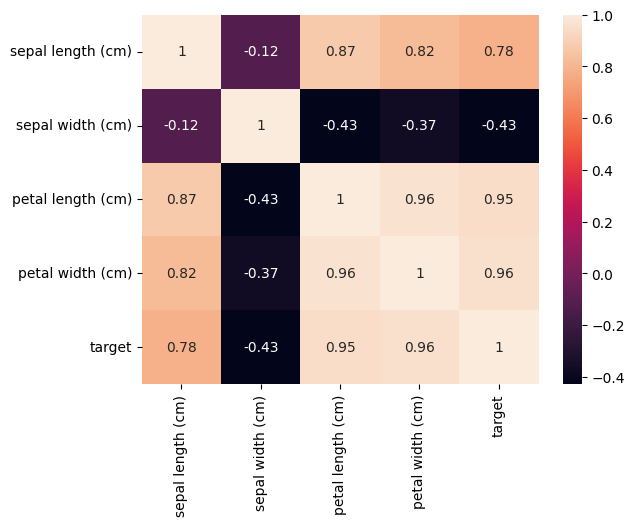

In [1103]:
#### get the graphical representation between all the numerical columns in the dataset

sns.heatmap(df.corr(), annot=True)

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1104]:
#### To check for the NULL records in the dataset

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1105]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


#### OBSERVATIONS:

1.  There is only one duplicate record in the dataset. So remove it.

In [1106]:
#### Remove the duplicate record from the dataset

df = df.drop_duplicates()

In [1107]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.


In [1108]:
#### Rename the columns

df.rename(columns={"sepal length (cm)" : "sepal_length"    ,
                   "sepal width (cm)" : "sepal_width"      ,
                   "petal length (cm)" : "petal_length"    ,
                   "petal width (cm)"  :  "petal_width"}, inplace=True)

In [1109]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### OBSERVATIONS:

1.  Now all the columns have been renamed to their proper column names.

In [1110]:
#### Again check the length of the records in the dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 149


#### OBSERVATIONS:

1.  The length of the dataset has decreased from 150 to 149 as one duplicate record has been removed from the dataset.

#### Step 5:    Divide the dataset into independent and dependent variables

In [1111]:
#### independent variables

X = df.drop(columns='target',axis=1)

print(X)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[149 rows x 4 columns]


In [1112]:
#### dependent variables

Y = df['target']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 149, dtype: int64


#### Step 7: Divide the independent and dependent variables into training and testing data

In [1113]:
from sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

In [1114]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
6,4.6,3.4,1.4,0.3
128,6.4,2.8,5.6,2.1
95,5.7,3.0,4.2,1.2
44,5.1,3.8,1.9,0.4
30,4.8,3.1,1.6,0.2
...,...,...,...,...
52,6.9,3.1,4.9,1.5
47,4.6,3.2,1.4,0.2
102,7.1,3.0,5.9,2.1
124,6.7,3.3,5.7,2.1


In [1115]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
69,5.6,2.5,3.9,1.1
66,5.6,3.0,4.5,1.5
141,6.9,3.1,5.1,2.3
7,5.0,3.4,1.5,0.2
147,6.5,3.0,5.2,2.0
57,4.9,2.4,3.3,1.0
84,5.4,3.0,4.5,1.5
28,5.2,3.4,1.4,0.2
138,6.0,3.0,4.8,1.8
127,6.1,3.0,4.9,1.8


In [1116]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (119, 4)
Shape of the input testing  data is: (30, 4)


In [1117]:
Y_train

6      0
128    2
95     1
44     0
30     0
      ..
52     1
47     0
102    2
124    2
16     0
Name: target, Length: 119, dtype: int64

In [1118]:
Y_test

69     1
66     1
141    2
7      0
147    2
57     1
84     1
28     0
138    2
127    2
20     0
42     0
18     0
93     1
140    2
22     0
77     1
14     0
107    2
38     0
63     1
134    2
41     0
10     0
96     1
51     1
104    2
116    2
132    2
56     1
Name: target, dtype: int64

In [1119]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (119,)
Shape of the output testing  data is: (30,)


#### Step 8: Perform Feature Scaling on the inputs

In [1120]:
from sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, train and transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [1121]:
X_train_scaled

array([[-1.50158712,  0.7690314 , -1.33909259, -1.17973677],
       [ 0.63982407, -0.58674247,  1.04183404,  1.1863645 ],
       [-0.19294695, -0.13481785,  0.24819183,  0.00331387],
       [-0.90675068,  1.67288064, -1.05564894, -1.0482867 ],
       [-1.26365254,  0.09114446, -1.22571513, -1.31118684],
       [-0.43088152, -1.49059172,  0.02143691, -0.1281362 ],
       [ 0.63982407, -0.81270478,  0.87176786,  0.92346436],
       [ 0.52085678,  0.54306908,  1.26858896,  1.71216479],
       [ 2.18639882, -0.58674247,  1.66541007,  1.05491443],
       [ 1.59156238, -0.13481785,  1.1552115 ,  0.52911415],
       [-0.19294695,  3.02865451, -1.28240386, -1.0482867 ],
       [ 0.52085678, -0.36078016,  1.04183404,  0.79201429],
       [ 0.99672594,  0.54306908,  1.09852277,  1.71216479],
       [ 0.52085678, -0.58674247,  0.7583904 ,  0.39766408],
       [-0.43088152,  2.57672988, -1.33909259, -1.31118684],
       [ 0.87775865, -0.36078016,  0.47494675,  0.13476394],
       [-0.43088152, -1.

In [1122]:
X_test_scaled

array([[-0.31191424, -1.26462941,  0.07812564, -0.1281362 ],
       [-0.31191424, -0.13481785,  0.41825802,  0.39766408],
       [ 1.23466052,  0.09114446,  0.7583904 ,  1.44926464],
       [-1.02571797,  0.7690314 , -1.28240386, -1.31118684],
       [ 0.75879136, -0.13481785,  0.81507913,  1.05491443],
       [-1.14468525, -1.49059172, -0.26200673, -0.25958627],
       [-0.54984881, -0.13481785,  0.41825802,  0.39766408],
       [-0.78778339,  0.7690314 , -1.33909259, -1.31118684],
       [ 0.16395492, -0.13481785,  0.58832421,  0.79201429],
       [ 0.28292221, -0.13481785,  0.64501294,  0.79201429],
       [-0.54984881,  0.7690314 , -1.1690264 , -1.31118684],
       [-1.7395217 ,  0.31710677, -1.39578132, -1.31118684],
       [-0.19294695,  1.67288064, -1.1690264 , -1.17973677],
       [-1.02571797, -1.71655403, -0.26200673, -0.25958627],
       [ 0.99672594,  0.09114446,  1.04183404,  1.58071472],
       [-1.50158712,  1.22095602, -1.56584751, -1.31118684],
       [ 0.99672594, -0.

#### OBSERVATIONS:

1.  All the input features have been transformed in the same scale range of inputs between -1 to 1.

#### Step 9: Train the Decision Tree Classifier Model

In [1123]:
from  sklearn.tree  import  DecisionTreeClassifier

#### create the object of DecisionTreeClassifier

dec = DecisionTreeClassifier(criterion = 'entropy', random_state=42)

#### using the object of decision tree classifier, train the model

dec.fit(X_train_scaled, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

#### Step 10: Predict the model

In [1124]:
Y_pred = dec.predict(X_test_scaled)

In [1125]:
Y_pred

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

#### Step 11: Compare the Actual Results vs Predicted Results

In [1126]:
df_compare = pd.DataFrame({
    "Y_test": Y_test.values                ,
    "Y_pred": Y_pred                                     
})

In [1127]:
df_compare

,Y_test,Y_pred
0,1,1
1,1,1
2,2,2
3,0,0
4,2,2
5,1,1
6,1,1
7,0,0
8,2,2
9,2,2


#### Step 12: Perform Classification Evaluation Metrics

In [1128]:
from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.33333333333333
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of the Iris Plant species dataset using Decision Tree Classifier of Entropy method is 93.33

2.  The accuracy of the model is very high. So the model is working fine.

#### Step 13: Perform Testing on the sample data

In [1129]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = dec.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[[-0.90675068  0.99499371 -1.33909259 -1.31118684]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1130]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = dec.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[[1.3536278  0.31710677 0.53163548 0.26621401]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1131]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = dec.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[[0.52085678 0.54306908 1.26858896 1.71216479]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 14: Plot the Decision Tree Classifier

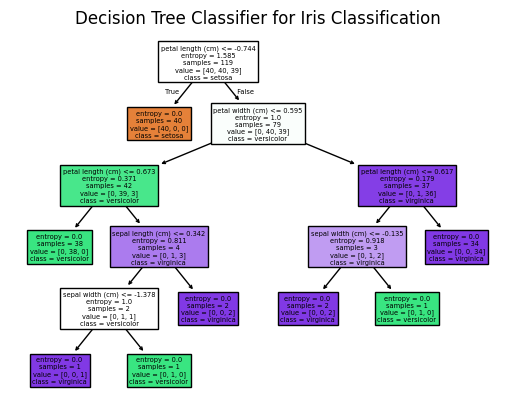

In [1132]:
from sklearn.tree  import  plot_tree

plot_tree(dec, filled = True, feature_names = data.feature_names,  class_names = data.target_names)

plt.title("Decision Tree Classifier for Iris Classification")

plt.show()

#### Step 15: Perform Hyper Parameter Tuning using Grid Search CV

In [1133]:
#### Define the pipeline

from  sklearn.pipeline  import  Pipeline

pipeline = Pipeline([
    ("sc"      ,          StandardScaler())                     ,
    ("dec"     ,          DecisionTreeClassifier(random_state=42) )
 ])

In [1134]:
#### define the parameter grid

param_grid = {
    'dec__criterion'         :      ['entropy', 'gini', 'log_loss']                  ,
    'dec__max_depth'         :      [None, 2, 3, 4, 5, 10]                           ,
    'dec__min_samples_split' :      [2, 5, 10, 20]                                   ,
    'dec__min_samples_leaf'  :      [1, 2, 5, 10]                                    ,
    'dec__max_features'      :      [None, 'sqrt', 'log2']
}

#### OBSERVATIONS:

1.  dec__criterion =================> It determines how the decision tree measures the quality of the split.

2.  dec__max_depth =================> It determies the maximum depth in the decision tree.

3.  dec__min_samples_split ==========> It determies the minimum samples required to split the leaf node.

4.  dec__min_samples_leaf ===========> It determines the minimum number of samples in a leaf node.

5.  dec__max_features ===============> It determines the maximum number of features considered for splitting the leaf node.

In [1135]:
#### perform the cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [1136]:
#### create the object of GridSearchCV

grid = GridSearchCV(
    pipeline                                                                        ,
    param_grid             =                   param_grid                           ,
    cv                     =                     cv                                 ,
    scoring                =                   'accuracy'                           ,
    n_jobs                 =                      -1 
)

In [1137]:
#### Train the Grid Search CV

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('dec',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'dec__criterion': ['entropy', 'gini', 'log_loss'],
                         'dec__max_depth': [None, 2, 3, 4, 5, 10],
                         'dec__max_features': [None, 'sqrt', 'log2'],
                         'dec__min_samples_leaf': [1, 2, 5, 10],
                         'dec__min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [1138]:
#### Obtain the best parameters and estimator of the model

best_parameter = grid.best_params_

print("Best parameter of the model is:", best_parameter)

Best parameter of the model is: {'dec__criterion': 'entropy', 'dec__max_depth': None, 'dec__max_features': 'sqrt', 'dec__min_samples_leaf': 1, 'dec__min_samples_split': 10}


In [1139]:
best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('dec',
                 DecisionTreeClassifier(criterion='entropy',
                                        max_features='sqrt',
                                        min_samples_split=10,
                                        random_state=42))])


In [1140]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [1141]:
Y_pred_grid

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

In [1142]:
#### Evaluate the Classification metrics

from        sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.33333333333333
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of the model is still 93.33 even after performing hyper parameter tuning using GridSearchCV.

2.  The accuracy is the same as earlier.

#### Step 16: Predict the Species of the Iris Plant based on the sample data

In [1143]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1144]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1145]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 17: Plot the DecisionTreeClassifier after erforming Hyper Parameter Tuning

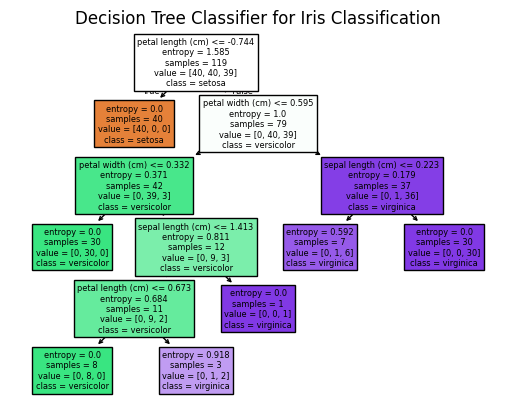

In [1146]:
from sklearn.tree  import  plot_tree

plot_tree(best_estimator.named_steps['dec'], filled = True, feature_names = data.feature_names,  class_names = data.target_names)

plt.title("Decision Tree Classifier for Iris Classification")

plt.show()